In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/merged_submissions.jsonl

/content/drive/MyDrive/merged_submissions.jsonl


In [ ]:
import torch
print(torch.cuda.is_available())  # Should be True

True


In [ ]:
!pip install bertopic
!pip install emoji
!pip install langdetect
!pip install spacy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [ ]:
import pandas as pd
from networkx.classes import non_neighbors
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import logging
from sklearn.decomposition import IncrementalPCA
from sklearn.cluster import MiniBatchKMeans
from bertopic.vectorizers import OnlineCountVectorizer
import re
import emoji
from langdetect import detect
from multiprocessing import Pool, cpu_count
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing
import spacy
import time
from tqdm import tqdm
import os
import psutil
import json
import sys
import datetime
from torch.utils.data import DataLoader

In [ ]:
# Set up logging to print to stdout and flush immediately
logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)]
)

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

In [ ]:
# Load spaCy once
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def is_english(text):
    try:
        return detect(text) == 'en'
    except:
        return False

def clean_text(text):
    if not isinstance(text, str) or len(text) < 5:
        return None

    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r"u/\w+|r/\w+|>\s.*", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()

    if not is_english(text):
        return None

    return text.strip()

def preprocess_texts(texts):
    logger.info(f"Starting preprocessing of {len(texts)} texts...")

    # Clean texts with progress bar
    cleaned = []
    for text in tqdm(texts, desc="Cleaning"):
        result = clean_text(text)
        if result and len(result.split()) > 3:
            cleaned.append(result)

    logger.info(f"Retained {len(cleaned)} texts after cleaning.")

    # Lemmatize with spaCy using progress-aware batching
    lemmatized = []
    logger.info("Starting lemmatization...")
    for doc in tqdm(nlp.pipe(cleaned, batch_size=1000), total=len(cleaned), desc="Lemmatizing"):
        tokens = [t.lemma_ for t in doc if not t.is_stop and t.is_alpha]
        if tokens:
            lemmatized.append(" ".join(tokens))

    logger.info("Lemmatization complete.")
    return lemmatized

In [ ]:
def process_docs(chunk):
    chunk = chunk[['title', 'selftext']].fillna('').astype(str)
    texts = (chunk['title'] + ' ' + chunk['selftext']).tolist()
    return process_docs_parallel(texts)

In [ ]:
def batched_encode(model, docs, batch_size=64):
    embeddings = []
    dataloader = DataLoader(docs, batch_size=batch_size)
    for batch in tqdm(dataloader, desc="Encoding batches"):
        emb = model.encode(batch, convert_to_numpy=True, show_progress_bar=False)
        embeddings.append(emb)  # Use append, not extend

    # Combine into a single 2D NumPy array
    logger.info(f"Embedding shape: {embeddings.shape}")
    return np.vstack(embeddings)

In [ ]:
def run_topic_modeling_partial(
    path,
    chunk_size=100_000,
    batch_size=64,
    min_topic_size=10,
    checkpoint_every=5,
    output_dir="bertopic_output"
):
    os.makedirs(output_dir, exist_ok=True)

    # Device setup
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    logger.info(f"Using device: {device}")

    # Data loader
    reader = pd.read_json(path, lines=True, chunksize=chunk_size)

    # Embedding model
    embedding_model = SentenceTransformer(
        'flax-sentence-embeddings/reddit_single-context_mpnet-base',
        device=device
    )

    # Dimensionality reduction
    umap_model = IncrementalPCA(n_components=15)

    # Clustering
    cluster_model = MiniBatchKMeans(
        n_clusters=100,
        batch_size=1000,
        random_state=42
    )

    # Vectorizer
    vectorizer_model = OnlineCountVectorizer(
        stop_words="english",
        decay=0.005,
        min_df=1,
        ngram_range=(1, 2)
    )

    # BERTopic
    topic_model = BERTopic(
        embedding_model=None,  # We'll use precomputed embeddings
        umap_model=umap_model,
        hdbscan_model=cluster_model,
        vectorizer_model=vectorizer_model,
        nr_topics=20,
        min_topic_size=min_topic_size,
        calculate_probabilities=True,
        verbose=True,
    )

    all_docs = []
    all_topics = []
    total_chunks = 0

    logger.info("Starting chunked topic modeling...")

    for i, chunk in enumerate(reader):
        start_time = time.time()
        try:
            logger.info(f"--- Processing chunk {i + 1} ---")

            docs = process_docs(chunk)
            if not docs:
                logger.warning(f"Chunk {i + 1} is empty after preprocessing. Skipping.")
                continue

            embeddings = batched_encode(embedding_model, docs, batch_size=batch_size)
            logger.info(f"Chunk {i + 1}: {len(docs)} documents encoded.")

            if i == 0:
                topic_model.fit(docs, embeddings=embeddings)
                logger.info("Initial fit completed.")
            else:
                topic_model.partial_fit(docs, embeddings=embeddings)
                logger.info(f"Partial fit completed on chunk {i + 1}.")

            all_docs.extend(docs)
            all_topics.extend(topic_model.topics_)
            total_chunks += 1

            elapsed = time.time() - start_time
            mem_used = psutil.virtual_memory().percent
            logger.info(f"Chunk {i + 1} done in {elapsed:.2f}s, Memory usage: {mem_used:.1f}%")

            # Save intermediate results
            if (i + 1) % checkpoint_every == 0:
                checkpoint_path = os.path.join(output_dir, f"bertopic_checkpoint_{i+1}.model")
                topic_model.save(checkpoint_path)
                logger.info(f"Checkpoint saved at: {checkpoint_path}")

        except Exception as e:
            logger.error(f"Error processing chunk {i + 1}: {str(e)}", exc_info=True)

    # Final model save
    topic_model.topics_ = all_topics
    final_model_path = os.path.join(output_dir, "bertopic_final.model")
    topic_model.save(final_model_path)
    logger.info(f"Final model saved at: {final_model_path}")

    # Save topics CSV
    topics_df = pd.DataFrame(all_topics)
    topics_csv_path = os.path.join(output_dir, "all_topics.csv")
    topics_df.to_csv(topics_csv_path, index=False)
    logger.info(f"Topics saved to: {topics_csv_path}")

    # Save model metadata
    metadata = {
        "timestamp": datetime.now().isoformat(),
        "chunks_processed": total_chunks,
        "total_docs": len(all_docs),
        "params": {
            "embedding_model": 'flax-sentence-embeddings/reddit_single-context_mpnet-base',
            "chunk_size": chunk_size,
            "batch_size": batch_size,
            "min_topic_size": min_topic_size,
            "n_components": 15,
            "n_clusters": 100,
            "vectorizer": {
                "decay": 0.005,
                "min_df": 1,
                "ngram_range": (1, 2)
            }
        }
    }

    metadata_path = os.path.join(output_dir, "model_metadata.json")
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=2)
    logger.info(f"Model metadata saved to: {metadata_path}")

    return topic_model

In [ ]:
path = "/content/drive/MyDrive/merged_submissions.jsonl"
topic_model = run_topic_modeling_partial(path)

# Get topic info
topic_info = topic_model.get_topic_info()
topic_info.to_csv('TopicModelling_merged_reddit_embedding_model.csv', index=False)

INFO:__main__:Using device: cuda
INFO:__main__:Starting chunked topic modeling...
INFO:__main__:--- Processing chunk 1 ---
INFO:__main__:Preprocessing 100000 texts...
INFO:__main__:Retained 94776 texts after cleaning.
INFO:__main__:Starting lemmatization...
INFO:__main__:Lemmatization complete.
Encoding batches:   0%|          | 0/1481 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Encoding batches:   0%|          | 1/1481 [00:00<06:04,  4.06it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Encoding batches:   0%|          | 2/1481 [00:00<07:48,  3.16it/s]

...

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Encoding batches:  13%|█▎        | 195/1481 [01:19<12:28,  1.72it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Encoding batches:  13%|█▎        | 196/1481 [01:19<11:29,  1.86it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
for col in df.columns:
    print(col)

In [ ]:
print(df.shape)
print(df.info())
print(df.describe(include='all'))

(1390597, 135)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1390597 entries, 0 to 1390596
Columns: 135 entries, archived to year
dtypes: bool(2), datetime64[ns, UTC](1), float64(68), int32(1), int64(3), object(60)
memory usage: 1.4+ GB
None


In [ ]:
Missing values by column

In [ ]:
print(df.isnull().sum().sort_values(ascending=False).head(20))

year
2008      7951
2009     25126
2010     25763
2011     29626
2012     68243
2013     84096
2014     75806
2015     92896
2016    140951
2017    123114
2018    141604
2019    110349
2020    118498
2021     92736
2022     78787
2023     81077
2024     93974
Name: count, dtype: int64


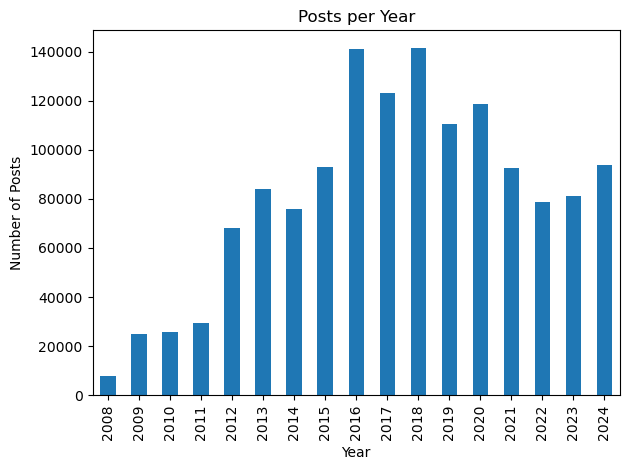

In [ ]:
df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s', utc=True)
df['year'] = df['created_utc'].dt.year
year_counts = df['year'].value_counts().sort_index()
print(year_counts)
year_counts = df.groupby(df['created_utc'].dt.year).size()

import matplotlib.pyplot as plt

year_counts.sort_index().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of Posts')
plt.title('Posts per Year')
plt.tight_layout()
plt.show()

In [ ]:
Topic modelling

In [ ]:
import logging

# Setup basic logging configuration
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

In [ ]:
import pandas as pd

sample_df = df.sample(n=500, random_state=42).fillna({"title": "", "selftext": ""})
docs = (sample_df['title'] + " " + sample_df['selftext']).tolist()
logger.info(f"Prepared {len(docs)} documents for topic modeling")

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

logger.info("Loading embedding model")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

logger.info("Initializing vectorizer and BERTopic")
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_df=0.85,
    min_df=2,
    max_features=3000
)
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    nr_topics="auto",
    top_n_words=10,
    calculate_probabilities=True,
    verbose=True  # Enables BERTopic’s built-in progress logging  [oai_citation:2‡Stack Overflow](https://stackoverflow.com/questions/76856592/jupyter-keeps-crashing-when-using-bertopics-fit-transform?utm_source=chatgpt.com)
)

In [ ]:
logger.info("Starting fit_transform() on sample documents")
topics, probs = topic_model.fit_transform(docs)
logger.info("Completed BERTopic modeling")

logger.info("Retrieving and displaying topic info")
topic_info = topic_model.get_topic_info()
topic_info.head()

In [ ]:
try:
    logger.info("Generating interactive topic visualization")
    fig = topic_model.visualize_topics()
    fig.write_html("sample_topic_vis.html")
    logger.info("Saved visualization to sample_topic_vis.html")
except Exception as e:
    logger.error(f"Visualization failed: {e}")